In [1]:
# load libraries
knitr::opts_chunk$set(echo = TRUE)
library(tidyverse)
library(mgcv)
library(ggbeeswarm)
library(gridExtra)
library(readxl)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
# Indicate path to allele data files. Currently needs to be the path to the directory where all results are stored
# i.e., within this path there are bioinformatic pipeline directories 
allele.data.path = "/Users/kmurie/Documents/git_projects/copy-number-variation/IMMRSE_data/mh/"
# allele.data.path = "/Users/kmurie/Documents/git_projects/copy-number-variation/IMMRSE_data/pfphast/"

# Indicate path to manifest indicating library preparation SuperBatches, Batches and controls. 
# Required columns are sample_name (string), CNVControl (TRUE/FALSE), Batch (numbers), SuperBatch (numbers), Run (string)
    # sample_name: ID for sample. It is okay if these are replicated across batches 
    # CNVControl: controls known NOT to have a CNV
    # Batch: a group of samples prepped together
    # SuperBatch: a group of Batches where the controls (and samples) look reasonably similar
    # Run : an ID for the sequencing run. This should match the folder name containing the mad4hatter pipeline results
# Note that controls/samples within a SuperBatch will be averaged and used to correct samples within that SuperBatch
manifest.path = "IMMRSE_data/manifests/mh_manifest.csv"
# manifest.path = "IMMRSE_data/manifests/pfphast_manifest.csv"

# Path to panel information and list of validated targets to include
panel.info.dir = "panel_information"
validated.target.filter.path = "panel_information/validated_target_filter.tsv"


# If TRUE, trims extra sequencing-related information from sample_name in allele table to match the manifest format
standardise_sample_name = TRUE
# If True, median of only controls will be used. If False, median of all samples and controls will be used
use.controls.only = FALSE

In [26]:
# Filters 

# Reaction thresholds
reaction.threshold.per.target =20 # number of reads each target must have on average within a reaction
Pools.ratio = 100 # maximum difference (fold change) between reads in the 2 reactions

# Filter to samples with a number of targets (ntarget.threshold) with over a certain number of reads (target.read.threshold)
target.read.threshold = 50 # min reads per locus
ntarget.proportion.threshold = 0.8 # proportion of amplicons with at least target.read.threshold reads

# Load files

In [6]:
# Read manifest
if (grepl("\\.csv$", manifest.path, ignore.case = TRUE)) {
  manifest <- read.csv(
    manifest.path,
    stringsAsFactors = FALSE
  )
} else if (grepl("\\.xlsx$", manifest.path, ignore.case = TRUE)) {
  manifest <- read_xlsx(manifest.path)
} else if (grepl("\\.tsv$", manifest.path, ignore.case = TRUE)) {
  manifest <- read.delim(
    manifest.path,
    stringsAsFactors = FALSE
  )
} else {
  stop("Manifest should be either a csv, tsv, or xlsx file")
}

#--------------------------------------------------
# Validate required columns
#--------------------------------------------------

required_columns <- c(
  "sample_name",
  "CNVControl",
  "Batch",
  "SuperBatch",
  "Run"
)

missing_columns <- setdiff(required_columns, colnames(manifest))

if (length(missing_columns) > 0) {

  stop(
    paste0(
      "Manifest is missing required columns: ",
      paste(missing_columns, collapse = ", ")
    )
  )
}

#--------------------------------------------------
# Validate column types/content
#--------------------------------------------------

# sample_name must be non-missing strings
if (
  any(is.na(manifest$sample_name)) ||
  any(trimws(manifest$sample_name) == "")
) {

  stop("sample_name contains missing or empty values")
}

manifest$sample_name <- as.character(manifest$sample_name)

# CNVControl must be TRUE/FALSE
valid_cnv <- manifest$CNVControl %in% c(TRUE, FALSE)

if (any(is.na(valid_cnv) | !valid_cnv)) {

  stop("CNVControl must contain only TRUE or FALSE values")
}

manifest$CNVControl <- as.logical(manifest$CNVControl)

# Batch must not be missing 
if (
  any(is.na(manifest$Batch))
) {

  stop("Batch contains missing or empty values")
}

# SuperBatch must be integer
if (
  any(is.na(manifest$SuperBatch))
) {

  stop("SuperBatch contains missing or empty values")
}


cat("Manifest validation passed")
manifest <- manifest %>% select("sample_name","Batch","CNVControl","SuperBatch","Run")

Manifest validation passed

In [7]:
# Process allele tables and find unique pools 

# Find allele tables
files <- list.files(
  path = allele.data.path,
  pattern = "allele_data.txt",
  recursive = TRUE,
  full.names = TRUE
)

required_columns <- c(
  "sample_name",
  "target_name",
  "reads",
  "pool"
)

# Function to read file and add metadata
read_and_add_filename <- function(file, required_columns) {
  data <- read.delim(file)

  missing_columns <- setdiff(required_columns, colnames(data))
  if (length(missing_columns) > 0) {
      stop(
        paste0(
          "allele data for ",basename(dirname(file))," is missing required columns: ",
          paste(missing_columns, collapse = ", ")
        )
      )
    }
    
  data$filename <- file
  data$Run <- basename(dirname(file))

  return(data)
}

# Read all files
allele.data <- map_df(files, read_and_add_filename, required_columns = required_columns)

# Trim sample name extensions if set
allele.data <- allele.data %>%
  mutate(sample_name = if (standardise_sample_name) sample_name %>%
           sub("_L001$", "", .) %>%
           word(., start = 1, end = -2, sep = "_") else sample_name)

In [8]:
# Find pools 
# Get unique pools per run
pool_check <- allele.data %>%
  
  # Split comma-separated pools into multiple rows
  separate_rows(pool, sep = ",") %>%
  
  # Remove whitespace around pool names
  mutate(pool = trimws(pool)) %>%
  
  group_by(Run) %>%
  summarise(
    pools = list(sort(unique(pool))),
    .groups = "drop"
  )

# Check whether all runs have identical pools
all_same <- length(unique(map_chr(pool_check$pools, paste, collapse = ","))) == 1

if (!all_same) {

  message("Pool mismatch detected between runs:\n")

  for (i in seq_len(nrow(pool_check))) {
    message(
      pool_check$Run[i],
      " -> ",
      paste(pool_check$pools[[i]], collapse = ", ")
    )
  }

  stop("Runs do not contain the same pool set.")
}

# Save the common pool set as parameter/object
unique_pools <- pool_check$pools[[1]]

cat("Pools:", paste(unique_pools, collapse = ", "))

Pools: D1.1, R1.2, R2.1

In [9]:
# Use pools to put together panel information 
cat('Panel Info Files\n')
amplicon.info <- map_df(unique_pools, function(pool_name) {

  file_path <- file.path(panel.info.dir, file.path(pool_name, paste0(pool_name, "_amplicon_info.tsv")))
  cat(paste0(file_path, '\n'))
  if (!file.exists(file_path)) {
    stop("Missing panel info file for pool: ", pool_name)
  }

  data <- read.delim(file_path)

  data$pool <- pool_name

  return(data)
})
# Group targets and put pools in one column
amplicon.info <- amplicon.info %>%
  group_by(target_name) %>%
  mutate(
    pool = paste(sort(unique(pool)), collapse = ",")
  ) %>%
  ungroup() %>%
  distinct()

# Check there aren't any duplicate targets left 
duplicate.targets <- amplicon.info %>%
  count(target_name) %>%
  filter(n > 1)

if (nrow(duplicate.targets) > 0) {

  warning(
    "Duplicate target_name entries found in amplicon.info: ",
    paste(duplicate.targets$target_name, collapse = ", ")
  )
}

# Add on amplicon length 
amplicon.info <- amplicon.info %>%
  mutate(
    amplicon_length = insert_end - insert_start
  )

Panel Info Files
panel_information/D1.1/D1.1_amplicon_info.tsv
panel_information/R1.2/R1.2_amplicon_info.tsv
panel_information/R2.1/R2.1_amplicon_info.tsv


In [10]:
# Put together targets of interest based on pools
cat('Targets of Interest Files\n')
target.of.interest <- map_df(unique_pools, function(pool_name) {
    
  file_path <- file.path(panel.info.dir, pool_name, paste0(pool_name, "_target_of_interest.tsv"))
  cat(paste0(file_path, '\n'))

  if (!file.exists(file_path)) {
    stop("Missing target of interest file for pool: ", pool_name)
  }

  data <- read.delim(file_path,stringsAsFactors = FALSE)

  # Handle empty files
  if (nrow(data) == 0) {
    data <- tibble(
      target_name = character(),
      pool = character()
    )
  } else {
    data$pool <- pool_name
  }

  return(data)
})

Targets of Interest Files
panel_information/D1.1/D1.1_target_of_interest.tsv
panel_information/R1.2/R1.2_target_of_interest.tsv
panel_information/R2.1/R2.1_target_of_interest.tsv


In [11]:
# Load target filter. Select only expected targets based on pools 
target.filter <- read_tsv(validated.target.filter.path, show_col_types = FALSE) %>%
  filter(target_name %in% amplicon.info$target_name) %>%
  pull(target_name)

In [12]:
# Filter to validated targets (excluding poor amplification and species targets)
allele.data.clean = allele.data %>% 
  filter(target_name %in% target.filter)

In [13]:
# Calculate read summary 
target.counts <- allele.data.clean %>%
  # Get reads per target 
  group_by(sample_name, filename, Run, target_name) %>%
  summarise(reads = sum(reads, na.rm = TRUE), .groups = "drop") %>%
  complete(sample_name, filename, Run, target_name = target.filter, fill = list(reads = 0)) %>%

  # Add pool column 
  left_join(amplicon.info %>% select('target_name','pool'), by = "target_name") %>%

  # Note: this will not work if targets are included which are in multiple reactions
  # These are currently all filtered out
  mutate(reaction = stringr::str_extract(pool, "[0-9]+")) %>%

  # Get reads per reaction 
  group_by(sample_name, filename, Run, reaction) %>%
  mutate(reaction_reads = sum(reads, na.rm = TRUE)) %>%
  ungroup() %>%

  # Count targets above threshold
  group_by(sample_name,filename,Run) %>%
  mutate(total_sample_reads = sum(reads), n_passed_targets = sum(reads > target.read.threshold,na.rm = TRUE)) %>%
  ungroup()

In [14]:
# Add on manifest and target information 
target.counts <- target.counts %>%
  left_join(amplicon.info %>% select(target_name,amplicon_length),by = c("target_name")) %>% 
  left_join(manifest,by=c("sample_name","Run"))
# TODO: add some checks. make sure samples are retained in both. Summary table of samples in each category 

In [27]:
# Calculate thresholds per reaction based on n targets
reaction.target.counts <- amplicon.info %>% 
  filter(target_name %in% target.filter) %>%
  mutate(reaction = stringr::str_extract(pool, "[0-9]+")) %>%
  group_by(reaction) %>%
  summarise(
    n_targets = n_distinct(target_name),
    .groups = "drop"
  ) %>%
  mutate(
    reaction.threshold = reaction.threshold.per.target * n_targets
  )

reaction1.threshold <- reaction.target.counts %>%
  filter(reaction == "1") %>%
  pull(reaction.threshold)

reaction2.threshold <- reaction.target.counts %>%
  filter(reaction == "2") %>%
  pull(reaction.threshold)

ntarget.threshold <- sum(reaction.target.counts$n_targets, na.rm = TRUE) *
  ntarget.proportion.threshold

In [31]:
# Identify QC pass samples 
samples.filtered <- target.counts %>%
  select(sample_name, filename, Run, SuperBatch, Batch,CNVControl, reaction, reaction_reads, n_passed_targets) %>%
  distinct() %>%
  pivot_wider(
    names_from = reaction,
    values_from = reaction_reads
  ) %>%
  rename(
    reaction1 = `1`,
    reaction2   = `2`
  ) %>%
  filter(
    reaction1 > reaction1.threshold,
    reaction2 > reaction2.threshold,
    n_passed_targets > ntarget.threshold,
    reaction1 / reaction2 < Pools.ratio,
    reaction2 / reaction1 < Pools.ratio
  )

# Filter to QC pass samples
target.counts.filtered <- target.counts %>%
  semi_join(samples.filtered,
            by = c("sample_name", "filename", "Run"))

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


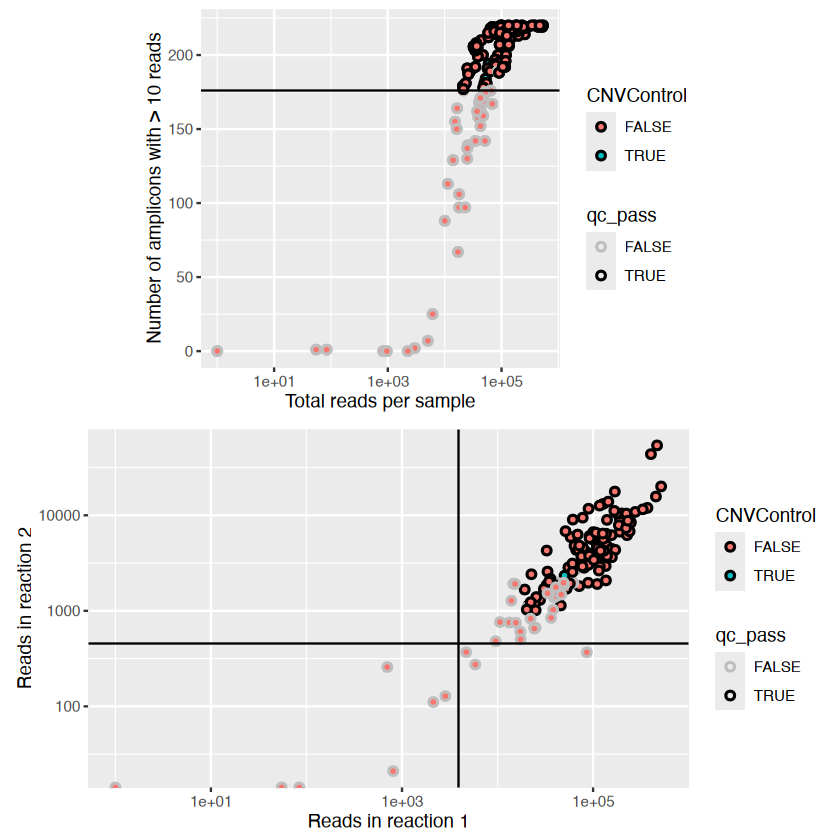

In [32]:
# Generate plot with total number of reads and number of amplicons with at least 10 reads
# Colors are taken from manifest
plots = list()
plots[[1]] = ggplot(target.counts %>%
                      select(sample_name,reaction,total_sample_reads,n_passed_targets,CNVControl) %>% 
                      distinct() %>% 
                      mutate(qc_pass= sample_name %in% samples.filtered$sample_name))+
  geom_point(aes(x = total_sample_reads,y=n_passed_targets,
                 color = qc_pass,
                 fill = CNVControl),
             shape=21,
             stroke =1)+
  scale_x_log10()+
  geom_hline(aes(yintercept = ntarget.threshold))+
  scale_color_manual(values=c("grey","black"))+
  theme(aspect.ratio = 1)+
  xlab("Total reads per sample")+
  ylab("Number of amplicons with > 10 reads")

plots[[2]] = ggplot(target.counts %>%
                      select(sample_name,reaction,reaction_reads,CNVControl) %>% 
                      distinct() %>% 
                      mutate(qc_pass= sample_name %in% samples.filtered$sample_name) %>% 
                      pivot_wider(names_from = reaction,values_from = reaction_reads) %>% 
                      rename(Reaction1 = "1",Reaction2 = "2"))+
  geom_point(aes(x = Reaction1,y=Reaction2,
                 color = qc_pass,
                 fill = CNVControl),
             shape=21,
             stroke =1)+
  scale_x_log10()+
  scale_y_log10()+
  geom_vline(aes(xintercept = reaction1.threshold))+
  geom_hline(aes(yintercept = reaction2.threshold))+
  scale_color_manual(values=c("grey","black"))+
  coord_fixed(ratio=1)+
  xlab("Reads in reaction 1")+
  ylab("Reads in reaction 2")


grid.arrange(grobs = plots, nrow = 2,ncol=1)

In [18]:
# Summary of number of samples per batch and class
summary = target.counts.filtered %>% 
  group_by(SuperBatch,CNVControl) %>% 
  summarise(n = n_distinct(sample_name)) %>% 
  mutate(CNVControl = ifelse(CNVControl, "# CNV controls","# non-CNV controls")) %>% 
  pivot_wider(names_from = CNVControl,values_from = n,values_fill = 0)

# Display the summary
summary  %>%
  kableExtra::kable() %>% 
  kableExtra::kable_styling(bootstrap_options = c("striped", "condensed"))

if(nrow(summary %>%
        group_by(SuperBatch) %>% 
        mutate(`Control-TRUE`=sum(`# CNV controls`)) %>% 
        filter(`Control-TRUE`==0))){
  paste("SuperBatch(s) with no CNV controls:",
        paste((summary %>%
                 group_by(SuperBatch) %>% 
                 mutate(`# CNV controls`=sum(`# CNV controls`)) %>% 
                 filter(`# CNV controls`==0))$SuperBatch,collapse=" "),
        ". Consider reassigning."
  )
}

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by SuperBatch and CNVControl.
ℹ Output is grouped by SuperBatch.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(SuperBatch, CNVControl))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


<table class="table table-striped table-condensed" style="margin-left: auto; margin-right: auto;">
 <thead>
  <tr>
   <th style="text-align:right;"> SuperBatch </th>
   <th style="text-align:right;"> # non-CNV controls </th>
   <th style="text-align:right;"> # CNV controls </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 137 </td>
   <td style="text-align:right;"> 4 </td>
  </tr>
</tbody>
</table>

In [19]:
# Add on the groups to the table 
target.counts.filtered <- target.counts.filtered %>%
  left_join(target.of.interest %>% select(target_name, group),by="target_name") %>%  # Add information on the targets of interest (what Group they belong to)
  mutate(group = ifelse(is.na(group),"NONE",group))

# Add columns for each target of interest Group and make them 1 for the corresponding targets
for (group.loci in unique(target.of.interest$group)) {
  target.counts.filtered = target.counts.filtered %>%
    mutate(!!group.loci := ifelse(group == !!group.loci, 1, 0))
}


In [20]:
estCNV <- function(data, sample.name="<sample>", verbose=F, k.gam=3,
                   plot.gam = F,
                   get.correction.factor = F,
                   # target.info = NULL,
                   loci.of.interest = NULL,
                   locus.filter = NULL,
                   ...){
  
  # Make Pool and Reaction factors (Reaction no longer used as per formula below)
  data = data %>% 
    mutate(Pool.factor = as.factor(pool),
           Reaction.factor = as.factor(reaction))
  
  # Get a list of groups of targets to report fold changes on
  group.of.interest.list = unique(loci.of.interest$group)
  
  # Define formula (spline the same for all groups, with Groups and Pools as variables)
  form <- as.formula(paste("reads ~ s(amplicon_length, k=k.gam) + Pool.factor +",
                           paste(group.of.interest.list,collapse=" + ")))
  
  # Get fit
  fit <- gam(form, data=data, family="poisson")
  
  
  if(get.correction.factor){  # This is run for controls (to get fold change in targets of interest to later normalize)
    
    # Make prediction frame to make plots with all data 
    pred.frame = expand_grid(amplicon_length=seq(floor(min(data$amplicon_length)),
                                                 ceiling(max(data$amplicon_length))),
                             Pool.factor = unique(data$Pool.factor))%>% 
      mutate(Reaction.factor = as.factor(substr(Pool.factor,2,2)))
    for (group.loci in group.of.interest.list) {
      pred.frame = pred.frame %>%
        mutate(!!group.loci := 0)
    }
    
    # Get predicted reads
    pred.frame$Reads = predict(fit,pred.frame,type="response")
    
    
    # Make a prediction frame for the targets we want residuals for
    targets.to.correct = target.of.interest %>% 
      rename(Locus="target_name",Group="group",Pool="pool") %>% 
      filter(Locus %in% target.filter) %>% 
      mutate(Reaction = substr(Pool,2,2)) %>% 
      left_join(amplicon.info %>% select(target_name,amplicon_length),by = c("Locus"="target_name")) 
    for (group.loci in unique(target.of.interest$group)) {
      targets.to.correct = targets.to.correct %>%
        mutate(!!group.loci := 0) # When getting correction factor don't use Groups as variable 
    }

    targets.to.correct = targets.to.correct %>% 
      mutate(Pool.factor = as.factor(Pool),
             Reaction.factor = as.factor(Reaction))
    targets.to.correct$ExpectedReads =round(predict(fit, newdata = targets.to.correct,type="response"))
    
    # Make a data frame with the predicted values and get the observed fold change with respect to expected
    data.prediction = data %>%
      filter(group %in% group.of.interest.list) %>% 
      left_join(targets.to.correct %>% select(Locus,ExpectedReads),
                by = c("target_name"="Locus")) %>% 
      mutate(FoldChange = reads/ExpectedReads) %>% 
      select(sample_name,group,target_name,reads,ExpectedReads,FoldChange)
    
    if(plot.gam){
      # Make a plot with the fit, per Pool
      plot.data <- ggplot() +
        geom_point(data = data, aes(x = amplicon_length, y = reads, color = group),alpha=1) +
        scale_color_manual(values = c("NONE" = "darkgray",
                                      "HRP2_DD2" = "darksalmon",
                                      "HRP2_P4" = "firebrick4",
                                      "HRP2_P34" = "firebrick3",
                                      "HRP3_P34" = "darkorchid3",
                                      "MDR1" = "dodgerblue4",
                                      "PM" = "darkgoldenrod",
                                      "CRT" = "darkgreen"))+
        geom_line(data = pred.frame, aes(x = amplicon_length, y = Reads),color="black")+
        facet_wrap(~Pool.factor) +
        ggtitle(paste("Sample:", sample.name,"\nRun:",data$Run[1],"Batch:",data$Batch[1]))+
        theme(legend.position = "right",
              plot.title = element_text(size = 7),
              axis.text = element_text(size = 5),
              axis.title = element_text(size=6),
              legend.title = element_text(size = 6,hjust=0.5),
              legend.text = element_text(size = 5, color = "black"),
              strip.text = element_text(size = 5),
              legend.key.size = unit(10,"points")
        )
      
      
      return(list(plot.data,data.prediction))
    }else{
      return(data.prediction)
    }
  }else{
    # If the function is used to get the fold change for each target group, return the coeficients
    coef <- summary(fit)$p.coef[group.of.interest.list]
    se <- summary(fit)$se[group.of.interest.list]
    
    return(list(Group = names(coef),FoldChangeGroup=exp(coef), Coef=coef, SE=se))
  }
}

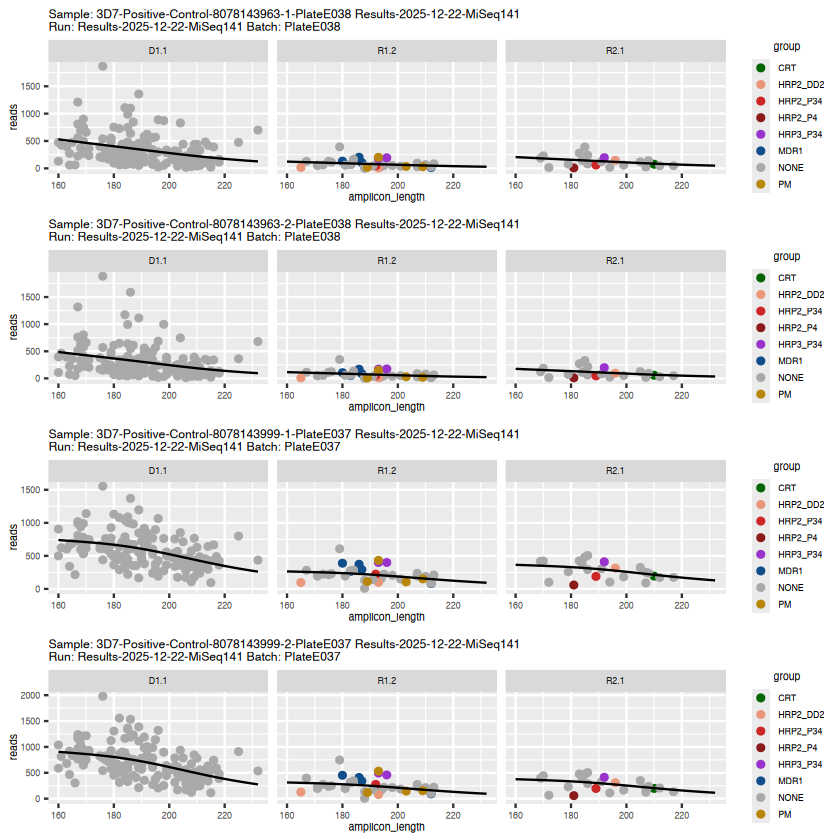

In [21]:
# Initialize with empty list for plots and tibble for prediction data
plot.controls = list()
# Get list of controls (taken from manifest)
controls = samples.filtered %>% 
  filter(CNVControl) %>% 
  select(sample_name,Run)


if( use.controls.only ){
  data.prediction = tibble()
  # Iterate over each control
  for(i in 1:nrow(controls)){
    data = target.counts.filtered %>% 
      filter(sample_name == controls$sample_name[i] & Run == controls$Run[i]) %>% 
      mutate(reads = ifelse(reads==0,1,reads)) # since the correction factor needs to be a number, make 0's 1
    control_name = paste(controls$sample_name[i],controls$Run[i])
    # Get fold change for targets of interest 
    output = estCNV(data,sample.name = control_name,plot.gam = T,get.correction.factor = T,loci.of.interest = target.of.interest, locus.filter = target.filter)
    plot.controls[control_name] = output[1]
    data.prediction = rbind(data.prediction,
                            output[[2]] %>% 
                              mutate(Run = controls$Run[i])%>% 
                              mutate(Locus.Group = paste(group,target_name))
    )
  }
}else{
  # Iterate over each control for plots # REPEATED CODE WATCH OUT - remove
    for(i in 1:nrow(controls)){
        data = target.counts.filtered %>% 
          filter(sample_name == controls$sample_name[i] & Run == controls$Run[i]) %>% 
          mutate(reads = ifelse(reads==0,1,reads)) # since the correction factor needs to be a number, make 0's 1
        control_name = paste(controls$sample_name[i],controls$Run[i])
        # Get fold change for targets of interest 
        output = estCNV(data,sample.name = control_name,plot.gam = T,get.correction.factor = T,loci.of.interest = target.of.interest, locus.filter = target.filter)
        plot.controls[control_name] = output[1]
  }
  
  
  data.prediction <- map_df(unique(paste(target.counts.filtered$sample_name, target.counts.filtered$Run, sep = ":")), function(sample_run) {
    parts <- strsplit(sample_run, ":")[[1]]
    sample.name <- parts[1]
    run.name <- parts[2]
    data <- filter(target.counts.filtered, sample_name == sample.name, Run == run.name)
    output <- estCNV(data, plot.gam = F, get.correction.factor = T,loci.of.interest = target.of.interest, locus.filter = target.filter)
    output %>% 
      mutate(Run = data$Run[1])%>%    # CHECK THIS
      mutate(Locus.Group = paste(group,target_name))
  })
}
# Add data from manifest
data.prediction = data.prediction %>% 
  left_join(manifest,by = join_by(sample_name,Run))
# Display all plots
grid.arrange(grobs = plot.controls, nrow = length(plot.controls))


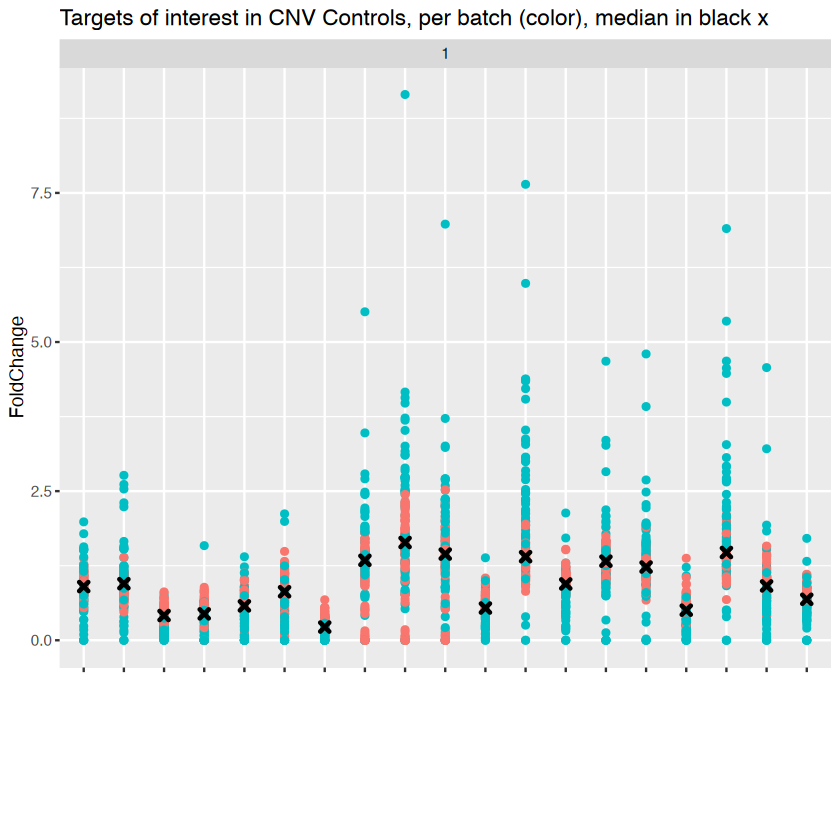

In [22]:
# Get median fold change for each target across controls in a SuperBatch
data.prediction.median = data.prediction %>% 
  group_by(target_name,SuperBatch,group) %>% 
  summarize(MedianFoldChange = median(FoldChange),.groups = 'drop') %>% 
  mutate(Locus.Group = paste(group,target_name))

# Plot Fold changes for each SuperBatch (colors = batch, cross = median)
ggplot(data.prediction)+
  geom_point(aes(x=Locus.Group,y = FoldChange,color = as.factor(Batch)))+
  geom_point(data = data.prediction.median,aes(x=Locus.Group,y = MedianFoldChange),shape=4,color="black",stroke=1.5)+
  theme(legend.position = "none",axis.text.x = element_text(size=4,angle = 90, hjust = 1))+
  guides(color = guide_legend(nrow = length(unique(data.prediction$sample_name))))+
  ggtitle("Targets of interest in CNV Controls, per batch (color), median in black x")+
  facet_wrap(~SuperBatch)+
  xlab("")

# At this point you may want to reassign batches

In [26]:
# Correct the reads in each sample by the correction factor for the targets of interest within the SuperBatch
target.counts.filtered.corrected = target.counts.filtered %>% 
  left_join(data.prediction.median,by=c("SuperBatch","target_name","group")) %>% 
  mutate(Correction.Factor = ifelse(is.na(MedianFoldChange),1,MedianFoldChange)) %>% 
  mutate(Reads.Uncorrected = reads,reads = round(Reads.Uncorrected/Correction.Factor))

fold.changes <- map_df(unique(paste(target.counts.filtered.corrected$sample_name, target.counts.filtered.corrected$Run, sep = ":")), function(sample_run) {
  parts <- strsplit(sample_run, ":")[[1]]
  sample.name <- parts[1]
  run.name <- parts[2]
  data <- filter(target.counts.filtered.corrected, sample_name == sample.name, Run == run.name)
  output <- estCNV(data, loci.of.interest = target.of.interest, locus.filter = target.filter)
  tibble(
    sample_name = sample.name,
    Run = run.name,
    group = output$Group,
    FoldChangeGroup = output$FoldChangeGroup,
    coef = output$Coef,
    se = output$SE
  )
})

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


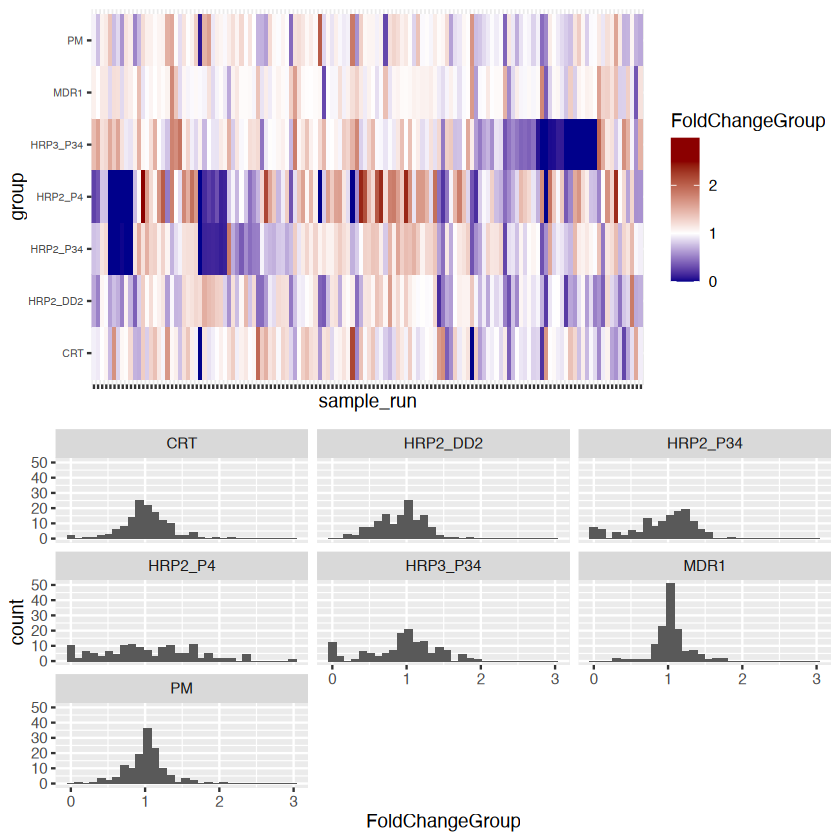

In [27]:
# To quickly visualize data, make a heatmap of fold changes in each gee of interest
plots = list()
plots[[1]] =ggplot(fold.changes %>% 
                     mutate(sample_run = paste(sample_name,Run)))+
  geom_tile(aes(y=group,x=sample_run,fill=FoldChangeGroup))+
  theme(axis.text.x = element_blank(),
        axis.text.y = element_text(size=6))+ 
  scale_fill_gradientn(
    colors = c("darkblue", "white", "darkred", "darkred"),
    values = scales::rescale(c(0, 1, 2.5, max(fold.changes$FoldChangeGroup))),
    limits = c(0, max(fold.changes$FoldChangeGroup))
  ) 

plots[[2]] =ggplot(fold.changes)+
  geom_histogram(aes(x=FoldChangeGroup))+
  facet_wrap(~group)
grid.arrange(grobs = plots, nrow = 2,ncol=1)

In [28]:
# Rename Groups to Genes and, for HRP2 get scores from the maximum of the 2 groups of targets 
fold.changes.final = fold.changes %>% 
  filter(group != "HRP2_DD2") %>% 
  mutate(gene = sapply(str_split(group,"_"),head,1)) %>% 
  group_by(sample_name,Run,gene) %>% 
  summarize(FoldChangeGene = max(FoldChangeGroup,na.rm = T))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sample_name, Run, and gene.
ℹ Output is grouped by sample_name and Run.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sample_name, Run, gene))` for per-operation grouping (`?dplyr::dplyr_by`) instead.


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


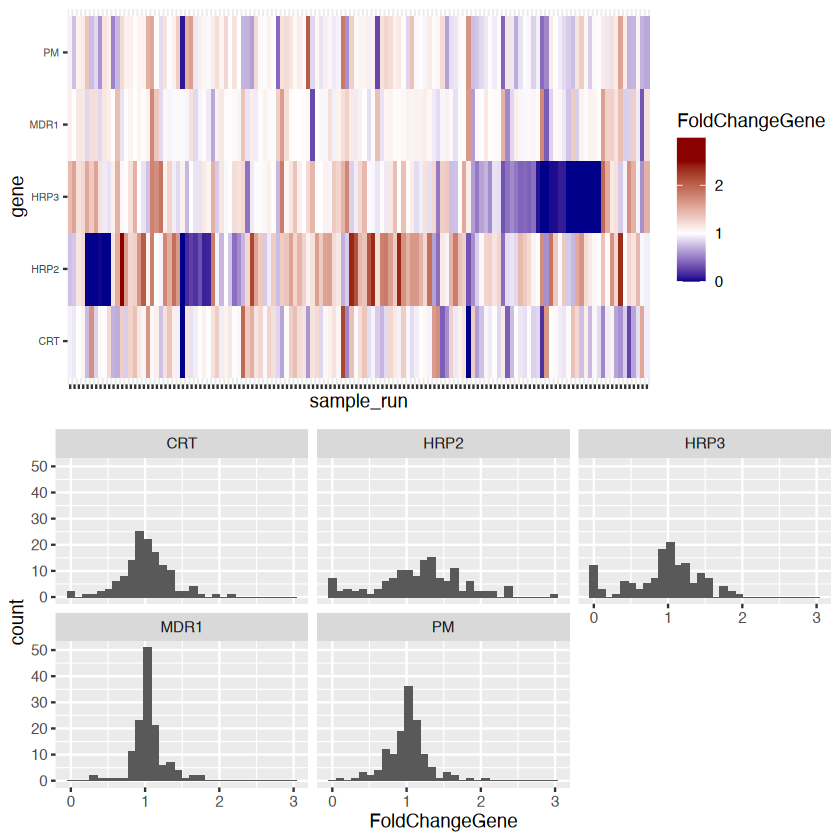

In [29]:
# To quickly visualize data, make a heatmap of fold changes in each gene of interest
plots = list()
plots[[1]] =ggplot(fold.changes.final %>% 
                     mutate(sample_run = paste(sample_name,Run)))+
  geom_tile(aes(x=sample_run,y=gene,fill=FoldChangeGene))+
  theme(axis.text.x = element_blank(),
        axis.text.y = element_text(size=6))+ 
  scale_fill_gradientn(
    colors = c("darkblue", "white", "darkred", "darkred"),
    values = scales::rescale(c(0, 1, 2.5, max(fold.changes.final$FoldChangeGene))),
    limits = c(0, max(fold.changes.final$FoldChangeGene))
  ) 

plots[[2]] =ggplot(fold.changes.final)+
  geom_histogram(aes(x=FoldChangeGene))+
  facet_wrap(~gene)
grid.arrange(grobs = plots, nrow = 2,ncol=1)

In [30]:
write.csv(fold.changes,file.path(allele.data.path,"fold_changes_output.csv"))
write.csv(fold.changes.final,file.path(allele.data.path,"fold_changes_final_output.csv"))